In [23]:
# Import ALL required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout,
    Conv1D, MaxPooling1D, Flatten,
    Input, LayerNormalization, GlobalAveragePooling1D,
    MultiHeadAttention
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Check for GPU
print("TensorFlow version:", tf.__version__)
print("GPU Available:", "YES" if tf.config.list_physical_devices('GPU') else "NO")
if tf.config.list_physical_devices('GPU'):
    print("GPU Device:", tf.config.list_physical_devices('GPU')[0])
print("\n✓ All libraries imported successfully!")

TensorFlow version: 2.19.0
GPU Available: YES
GPU Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

✓ All libraries imported successfully!


## 1. Data Loading

In [24]:
# Load the combined dataset
data = pd.read_csv("combined_banks_dataset.csv")
data['published_date'] = pd.to_datetime(data['published_date'])
data = data.sort_values(['company_id', 'published_date']).reset_index(drop=True)

print(f"{'='*60}")
print(f"Combined dataset loaded: {data.shape}")
print(f"Number of banks: {data['company_id'].nunique()}")
print(f"Banks: {sorted(data['company_id'].unique())}")
print(f"Date range: {data['published_date'].min()} to {data['published_date'].max()}")
print(f"{'='*60}")

Combined dataset loaded: (53063, 10)
Number of banks: 17
Banks: ['ADBL', 'CZBIL', 'EBL', 'GBIME', 'HBL', 'KBL', 'MBL', 'NABIL', 'NBL', 'NICA', 'NMB', 'PCBL', 'PRVU', 'SANIMA', 'SBI', 'SBL', 'SCB']
Date range: 2009-06-25 00:00:00 to 2025-12-29 00:00:00


In [25]:
# Quick data overview
data.head()

,published_date,open,high,low,close,per_change,traded_quantity,traded_amount,status,company_id
0,2010-09-16,117.0,122.0,116.0,120.0,NaN,5280.0,0.0,0,ADBL
1,2010-09-19,120.0,120.0,116.0,118.0,-1.67,2648.0,0.0,0,ADBL
2,2010-09-20,118.0,119.0,116.0,118.0,0.00,2346.0,0.0,0,ADBL
3,2010-09-21,118.0,118.0,115.0,116.0,-1.69,7160.0,0.0,0,ADBL
4,2010-09-23,116.0,120.0,117.0,120.0,3.45,8417.0,0.0,0,ADBL


## 2. Create Sequences (Per Company)
**Critical:** Sequences created within each company to prevent mixing.

In [26]:
def create_sequences_per_company(data, seq_length):
    """
    Create sequences for each company separately.
    Returns: X, y, company_ids, dates (last date in each sequence)
    """
    X, y, company_ids, dates = [], [], [], []

    for company in data['company_id'].unique():
        company_data = data[data['company_id'] == company].sort_values('published_date')
        prices = company_data['close'].values
        dates_arr = company_data['published_date'].values

        # Create sequences only within this company
        for i in range(seq_length, len(prices)):
            X.append(prices[i-seq_length:i])
            y.append(prices[i])
            company_ids.append(company)
            dates.append(dates_arr[i])  # Target date

    return np.array(X), np.array(y), np.array(company_ids), np.array(dates)

SEQ_LENGTH = 30

print(f"Creating sequences with length {SEQ_LENGTH}...")
X, y, company_ids, dates = create_sequences_per_company(data, SEQ_LENGTH)

print(f"\n{'='*60}")
print(f"Sequences created:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Companies: {len(np.unique(company_ids))}")
print(f"  Date range: {dates.min()} to {dates.max()}")
print(f"{'='*60}")

Creating sequences with length 30...

Sequences created:
  X shape: (52553, 30)
  y shape: (52553,)
  Companies: 17
  Date range: 2009-08-17T00:00:00.000000000 to 2025-12-29T00:00:00.000000000


## 3. Temporal Train-Test Split (FIX #2)

**FIXED:** Split by time, not by percentage. Last 20% of time period = test set.

In [27]:
# Calculate temporal cutoff (80% of time range)
min_date = dates.min()
max_date = dates.max()
date_range = (max_date - min_date)
cutoff_date = min_date + date_range * 0.8

print(f"Temporal Split:")
print(f"  Full date range: {min_date} to {max_date}")
print(f"  Cutoff date: {cutoff_date}")
print(f"  Train: samples before {cutoff_date}")
print(f"  Test:  samples on/after {cutoff_date}")

# Split by date
train_mask = dates < cutoff_date
test_mask = dates >= cutoff_date

X_train = X[train_mask]
y_train = y[train_mask]
company_train = company_ids[train_mask]
dates_train = dates[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]
company_test = company_ids[test_mask]
dates_test = dates[test_mask]

print(f"\nSplit results:")
print(f"  Train: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Train date range: {dates_train.min()} to {dates_train.max()}")
print(f"  Test date range:  {dates_test.min()} to {dates_test.max()}")
print(f"\n✓ No temporal overlap between train/test!")

Temporal Split:
  Full date range: 2009-08-17T00:00:00.000000000 to 2025-12-29T00:00:00.000000000
  Cutoff date: 2022-09-20T09:36:00.000000000
  Train: samples before 2022-09-20T09:36:00.000000000
  Test:  samples on/after 2022-09-20T09:36:00.000000000

Split results:
  Train: 40,064 samples (76.2%)
  Test:  12,489 samples (23.8%)
  Train date range: 2009-08-17T00:00:00.000000000 to 2022-09-20T00:00:00.000000000
  Test date range:  2022-09-21T00:00:00.000000000 to 2025-12-29T00:00:00.000000000

✓ No temporal overlap between train/test!


## 4. Scale Data - NO LEAKAGE (FIX #1)

**FIXED:** Fit scaler ONLY on training data, then transform both train and test.

In [28]:
# FIT scaler on training data ONLY
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(y_train.reshape(-1, 1))

print(f"Scaler Statistics (fitted on TRAINING data only):")
print(f"  Training price range: ${y_train.min():.2f} - ${y_train.max():.2f}")
print(f"  Test price range: ${y_test.min():.2f} - ${y_test.max():.2f}")
print(f"  Scaler min: {scaler.data_min_[0]:.2f}")
print(f"  Scaler max: {scaler.data_max_[0]:.2f}")

# Scale sequences (each sequence independently)
def scale_sequences(X, scaler):
    """Scale each sequence using the fitted scaler"""
    X_scaled = np.zeros_like(X, dtype=np.float32)
    for i in range(len(X)):
        X_scaled[i] = scaler.transform(X[i].reshape(-1, 1)).flatten()
    return X_scaled

# Transform train and test
X_train_scaled = scale_sequences(X_train, scaler)
y_train_scaled = scaler.transform(y_train.reshape(-1, 1)).flatten()

X_test_scaled = scale_sequences(X_test, scaler)
y_test_scaled = scaler.transform(y_test.reshape(-1, 1)).flatten()

print(f"\nScaled ranges:")
print(f"  X_train_scaled: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")
print(f"  X_test_scaled:  [{X_test_scaled.min():.4f}, {X_test_scaled.max():.4f}]")
print(f"\n✓ Scaler fitted on training data only - NO LEAKAGE!")

Scaler Statistics (fitted on TRAINING data only):
  Training price range: $98.00 - $3895.00
  Test price range: $130.40 - $913.00
  Scaler min: 98.00
  Scaler max: 3895.00

Scaled ranges:
  X_train_scaled: [0.0000, 1.0000]
  X_test_scaled:  [0.0085, 0.2146]

✓ Scaler fitted on training data only - NO LEAKAGE!


In [29]:
# Reshape for neural networks
X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print(f"Reshaped for neural networks:")
print(f"  X_train_3d: {X_train_3d.shape}")
print(f"  X_test_3d:  {X_test_3d.shape}")

Reshaped for neural networks:
  X_train_3d: (40064, 30, 1)
  X_test_3d:  (12489, 30, 1)


## 5. Naive Baseline (FIX #4)

**ADDED:** Compare models against simple baseline: tomorrow's price = today's price.

In [30]:
# Naive baseline: predict tomorrow = today (last value in sequence)
baseline_predictions_scaled = X_test_scaled[:, -1]  # Last value of each sequence
baseline_predictions = scaler.inverse_transform(baseline_predictions_scaled.reshape(-1, 1)).flatten()

# Calculate baseline metrics
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)
baseline_mape = np.mean(np.abs((y_test - baseline_predictions) / y_test)) * 100

print(f"{'='*60}")
print(f"NAIVE BASELINE (Tomorrow = Today)")
print(f"{'='*60}")
print(f"  RMSE: {baseline_rmse:.4f}")
print(f"  MAE:  {baseline_mae:.4f}")
print(f"  R²:   {baseline_r2:.4f}")
print(f"  MAPE: {baseline_mape:.2f}%")
print(f"\n⚠️  Models must beat this to be useful!")

NAIVE BASELINE (Tomorrow = Today)
  RMSE: 6.2629
  MAE:  3.6996
  R²:   0.9983
  MAPE: 1.18%

⚠️  Models must beat this to be useful!


## 6. Model Definitions

### 6.1 Simple LSTM

In [31]:
def build_lstm_simple(input_shape):
    """Simple LSTM following teacher's approach"""
    model = Sequential([
        LSTM(50, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

lstm_simple = build_lstm_simple((X_train_3d.shape[1], 1))
print("Simple LSTM Model:")
lstm_simple.summary()

Simple LSTM Model:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### 6.2 CNN Model

In [32]:
def build_cnn(input_shape):
    """1D CNN for time series"""
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(50, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

cnn_model = build_cnn((X_train_3d.shape[1], 1))
print("CNN Model:")
cnn_model.summary()

CNN Model:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 12, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │         9,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,133 (63.02 KB)

 Trainable params: 16,133 (63.02 KB)

 Non-trainable params: 0 (0.00 B)

### 6.3 Transformer Model

In [33]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    """Transformer encoder block"""
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs

    x = LayerNormalization(epsilon=1e-6)(res)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = Dropout(dropout)(x)
    return x + res

def build_transformer(input_shape, head_size=32, num_heads=4, ff_dim=128, num_blocks=2, dropout=0.2):
    """Transformer model"""
    inputs = Input(shape=input_shape)
    x = inputs

    for _ in range(num_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(dropout)(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

transformer_model = build_transformer((X_train_3d.shape[1], 1))
print("Transformer Model:")
transformer_model.summary()

Transformer Model:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ input_layer_5[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 1)     │        897 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 30, 1)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 1)     │          0 │ dropout_13[0][0], │
│                     │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 30, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 30, 128)   │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 30, 1)     │        129 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 30, 1)     │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 30, 1)     │          0 │ dropout_15[0][0], │
│                     │                   │            │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 1)     │        897 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 30, 1)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 30, 1)     │          0 │ dropout_17[0][0], │
│                     │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 30, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 30, 128)   │          0 │ dense_14[0][0]  

 Total params: 2,765 (10.80 KB)

 Trainable params: 2,765 (10.80 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training Configuration

In [34]:
EPOCHS = 50
BATCH_SIZE = 32

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

print("Training configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Early stopping: patience=10")
print(f"  LR reduction: factor=0.5, patience=5")

Training configuration:
  Epochs: 50
  Batch size: 32
  Early stopping: patience=10
  LR reduction: factor=0.5, patience=5


## 8. Model Training

### 8.1 Train Simple LSTM

In [35]:
print("="*70)
print("Training Simple LSTM")
print("="*70)

history_lstm_simple = lstm_simple.fit(
    X_train_3d, y_train_scaled,
    epochs=10,
    batch_size=BATCH_SIZE,
    verbose=0,
    validation_split=0.1
)

print("✓ Training completed!")

Training Simple LSTM
✓ Training completed!


### 8.2 Train CNN

In [36]:
print("="*70)
print("Training CNN")
print("="*70)

history_cnn = cnn_model.fit(
    X_train_3d, y_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_split=0.1,
    callbacks=callbacks
)

print("\n✓ Training completed!")

Training CNN
Epoch 1/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0018 - mae: 0.0219 - val_loss: 7.4236e-04 - val_mae: 0.0152 - learning_rate: 0.0010
Epoch 2/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.7090e-04 - mae: 0.0136 - val_loss: 3.9236e-04 - val_mae: 0.0111 - learning_rate: 0.0010
Epoch 3/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.2052e-04 - mae: 0.0134 - val_loss: 2.9569e-04 - val_mae: 0.0091 - learning_rate: 0.0010
Epoch 4/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.8220e-04 - mae: 0.0126 - val_loss: 4.5149e-04 - val_mae: 0.0131 - learning_rate: 0.0010
Epoch 5/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.4131e-04 - mae: 0.0123 - val_loss: 9.9187e-04 - val_mae: 0.0205 - learning_rate: 0.0010
Epoch 6/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.6194e-04 - mae: 0.0126 - val_loss: 2.0375e-04 - val_mae: 0.0072 - learning_rate: 0.0010
Epoch 7/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.1496e-04 - mae:

### 8.3 Train Transformer

In [37]:
print("="*70)
print("Training Transformer")
print("="*70)

history_transformer = transformer_model.fit(
    X_train_3d, y_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_split=0.1,
    callbacks=callbacks
)

print("\n✓ Training completed!")

Training Transformer
Epoch 1/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: 0.0059 - mae: 0.0398 - val_loss: 0.0044 - val_mae: 0.0427 - learning_rate: 0.0010
Epoch 2/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0038 - mae: 0.0290 - val_loss: 0.0058 - val_mae: 0.0495 - learning_rate: 0.0010
Epoch 3/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0036 - mae: 0.0282 - val_loss: 0.0048 - val_mae: 0.0425 - learning_rate: 0.0010
Epoch 4/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0038 - mae: 0.0288 - val_loss: 0.0057 - val_mae: 0.0484 - learning_rate: 0.0010
Epoch 5/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0037 - mae: 0.0283 - val_loss: 0.0043 - val_mae: 0.0411 - learning_rate: 0.0010
Epoch 6/50
1121/1127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - mae: 0.0286
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0037 - mae: 0.0286 - val_loss: 0.0046 - val_m

## 9. Evaluation - Compare with Baseline (FIX #3, #4)

In [45]:
def evaluate_model(model, model_name, X_test, y_test_scaled, y_test_actual, scaler):
    """Evaluate model and compare with baseline"""
    # Predictions
    pred_scaled = model.predict(X_test, verbose=0)
    pred = scaler.inverse_transform(pred_scaled).flatten()  # ✅ ADD .flatten()

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, pred))
    mae = mean_absolute_error(y_test_actual, pred)
    r2 = r2_score(y_test_actual, pred)

    # ✅ MAPE calculation (both are now 1D arrays)
    mape = np.mean(np.abs((y_test_actual - pred) / y_test_actual)) * 100

    print(f"\n{model_name} Performance:")
    print(f"  RMSE: {rmse:.4f} (baseline: {baseline_rmse:.4f}) → {((rmse-baseline_rmse)/baseline_rmse*100):+.1f}%")
    print(f"  MAE:  {mae:.4f} (baseline: {baseline_mae:.4f}) → {((mae-baseline_mae)/baseline_mae*100):+.1f}%")
    print(f"  R²:   {r2:.4f} (baseline: {baseline_r2:.4f})")
    print(f"  MAPE: {mape:.2f}% (baseline: {baseline_mape:.2f}%)")

    return pred, rmse, mae, r2, mape

In [46]:
# Evaluate all models
print("="*70)
print("MODEL EVALUATION RESULTS (vs BASELINE)")
print("="*70)

pred_lstm, rmse_lstm, mae_lstm, r2_lstm, mape_lstm = evaluate_model(
    lstm_simple, "Simple LSTM", X_test_3d, y_test_scaled, y_test, scaler
)

pred_cnn, rmse_cnn, mae_cnn, r2_cnn, mape_cnn = evaluate_model(
    cnn_model, "CNN", X_test_3d, y_test_scaled, y_test, scaler
)

pred_trans, rmse_trans, mae_trans, r2_trans, mape_trans = evaluate_model(
    transformer_model, "Transformer", X_test_3d, y_test_scaled, y_test, scaler
)

MODEL EVALUATION RESULTS (vs BASELINE)

Simple LSTM Performance:
  RMSE: 6.5168 (baseline: 6.2629) → +4.1%
  MAE:  3.9321 (baseline: 3.6996) → +6.3%
  R²:   0.9982 (baseline: 0.9983)
  MAPE: 1.23% (baseline: 1.18%)

CNN Performance:
  RMSE: 9.6319 (baseline: 6.2629) → +53.8%
  MAE:  6.8958 (baseline: 3.6996) → +86.4%
  R²:   0.9961 (baseline: 0.9983)
  MAPE: 2.34% (baseline: 1.18%)

Transformer Performance:
  RMSE: 67.4647 (baseline: 6.2629) → +977.2%
  MAE:  61.0741 (baseline: 3.6996) → +1550.8%
  R²:   0.8080 (baseline: 0.9983)
  MAPE: 26.15% (baseline: 1.18%)


## 10. Comparison Table - Honest Assessment

In [48]:
# Create comparison dataframe
results_df = pd.DataFrame({
    'Model': ['Naive Baseline', 'Simple LSTM', 'CNN', 'Transformer'],
    'RMSE': [baseline_rmse, rmse_lstm, rmse_cnn, rmse_trans],
    'MAE': [baseline_mae, mae_lstm, mae_cnn, mae_trans],
    'R²': [baseline_r2, r2_lstm, r2_cnn, r2_trans],
    'MAPE (%)': [baseline_mape, mape_lstm, mape_cnn, mape_trans]
})

results_df = results_df.sort_values('RMSE')

print("\n" + "="*70)
print("COMPLETE MODEL COMPARISON (Including Baseline)")
print("="*70)
print(results_df.to_string(index=False))
print("\nNote: Lower RMSE, MAE, MAPE are better. Higher R² is better.")

best_model = results_df.iloc[0]['Model']
print(f"\n🏆 Best performing model: {best_model}")

# Check if models beat baseline
if results_df[results_df['Model'] != 'Naive Baseline']['RMSE'].min() < baseline_rmse:
    improvement = (1 - results_df[results_df['Model'] != 'Naive Baseline']['RMSE'].min() / baseline_rmse) * 100
    print(f"✓ Best model improves over baseline by {improvement:.1f}%")
else:
    print(f"⚠️  WARNING: No model beats the naive baseline!")


COMPLETE MODEL COMPARISON (Including Baseline)
         Model      RMSE       MAE       R²  MAPE (%)
Naive Baseline  6.262922  3.699625 0.998345  1.183862
   Simple LSTM  6.516750  3.932138 0.998209  1.227776
           CNN  9.631918  6.895812 0.996087  2.335353
   Transformer 67.464708 61.074128 0.808009 26.154527

Note: Lower RMSE, MAE, MAPE are better. Higher R² is better.

🏆 Best performing model: Naive Baseline
⚠️  WARNING: No model beats the naive baseline!


## 11. Visualizations

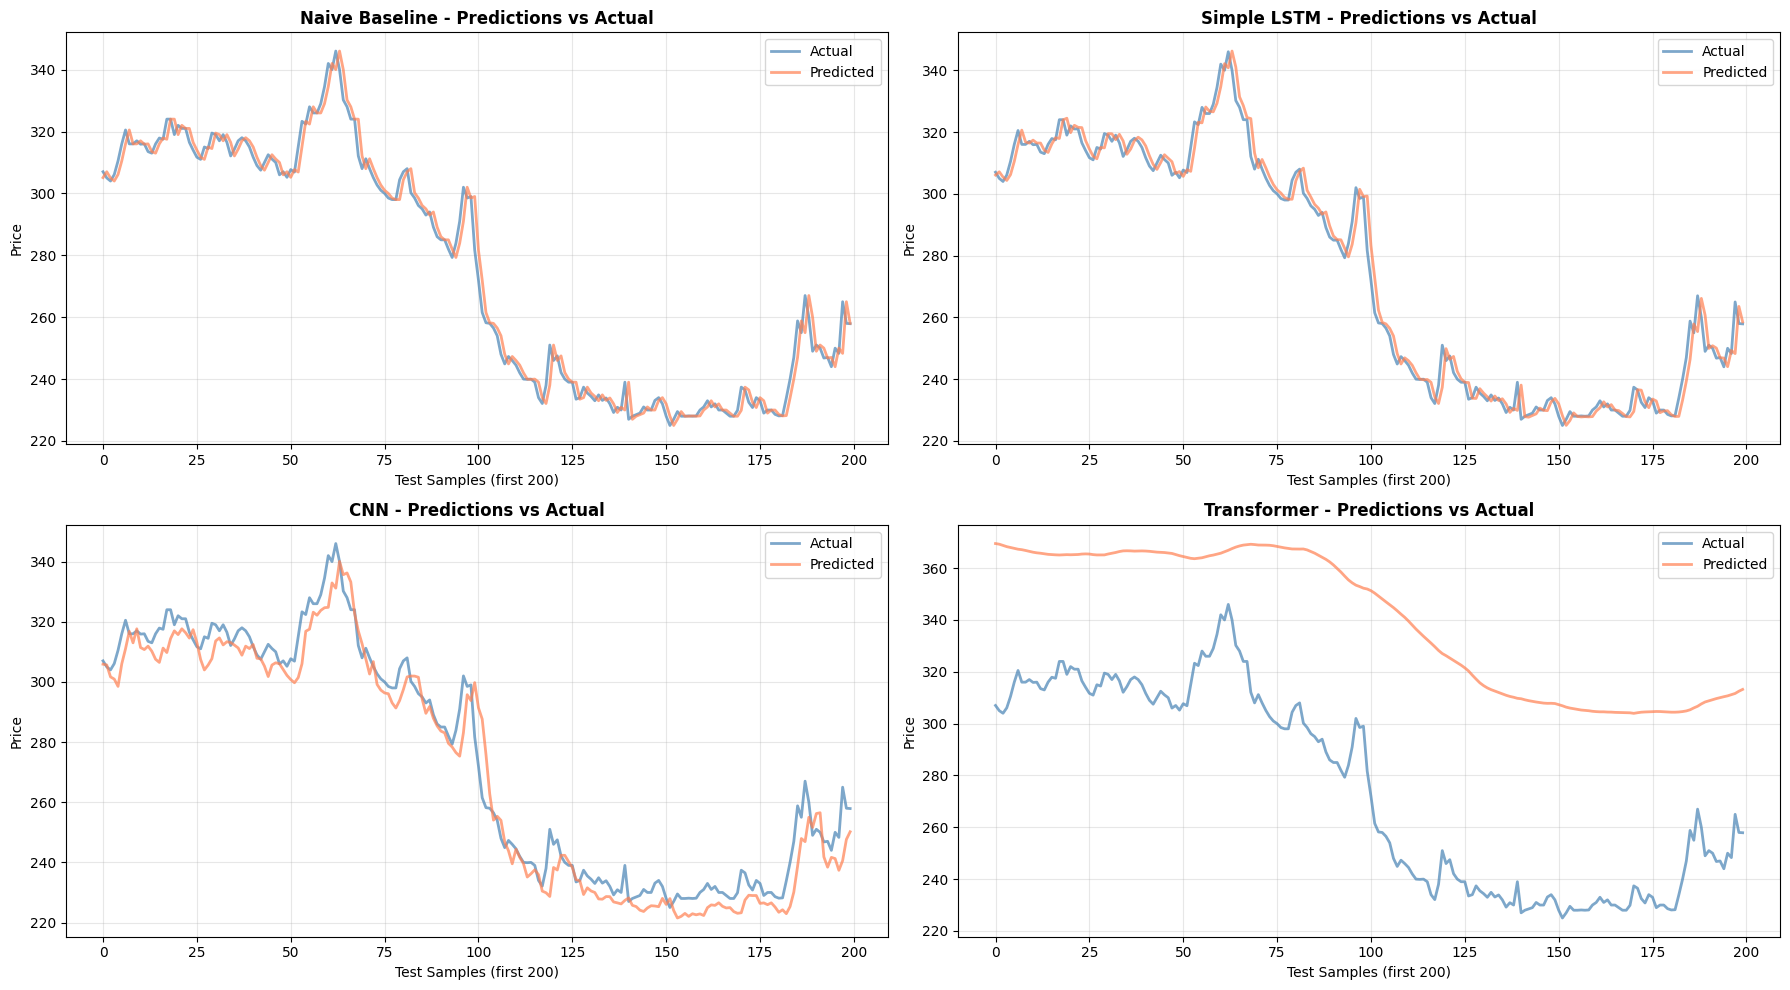

In [42]:
# Plot predictions vs actual (first 200 samples)
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

models_data = [
    ('Naive Baseline', baseline_predictions, y_test),
    ('Simple LSTM', pred_lstm.flatten(), y_test),
    ('CNN', pred_cnn.flatten(), y_test),
    ('Transformer', pred_trans.flatten(), y_test)
]

for idx, (name, pred, actual) in enumerate(models_data):
    axes[idx].plot(actual[:200], label='Actual', color='steelblue', linewidth=2, alpha=0.7)
    axes[idx].plot(pred[:200], label='Predicted', color='coral', linewidth=2, alpha=0.7)
    axes[idx].set_title(f'{name} - Predictions vs Actual', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Test Samples (first 200)')
    axes[idx].set_ylabel('Price')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

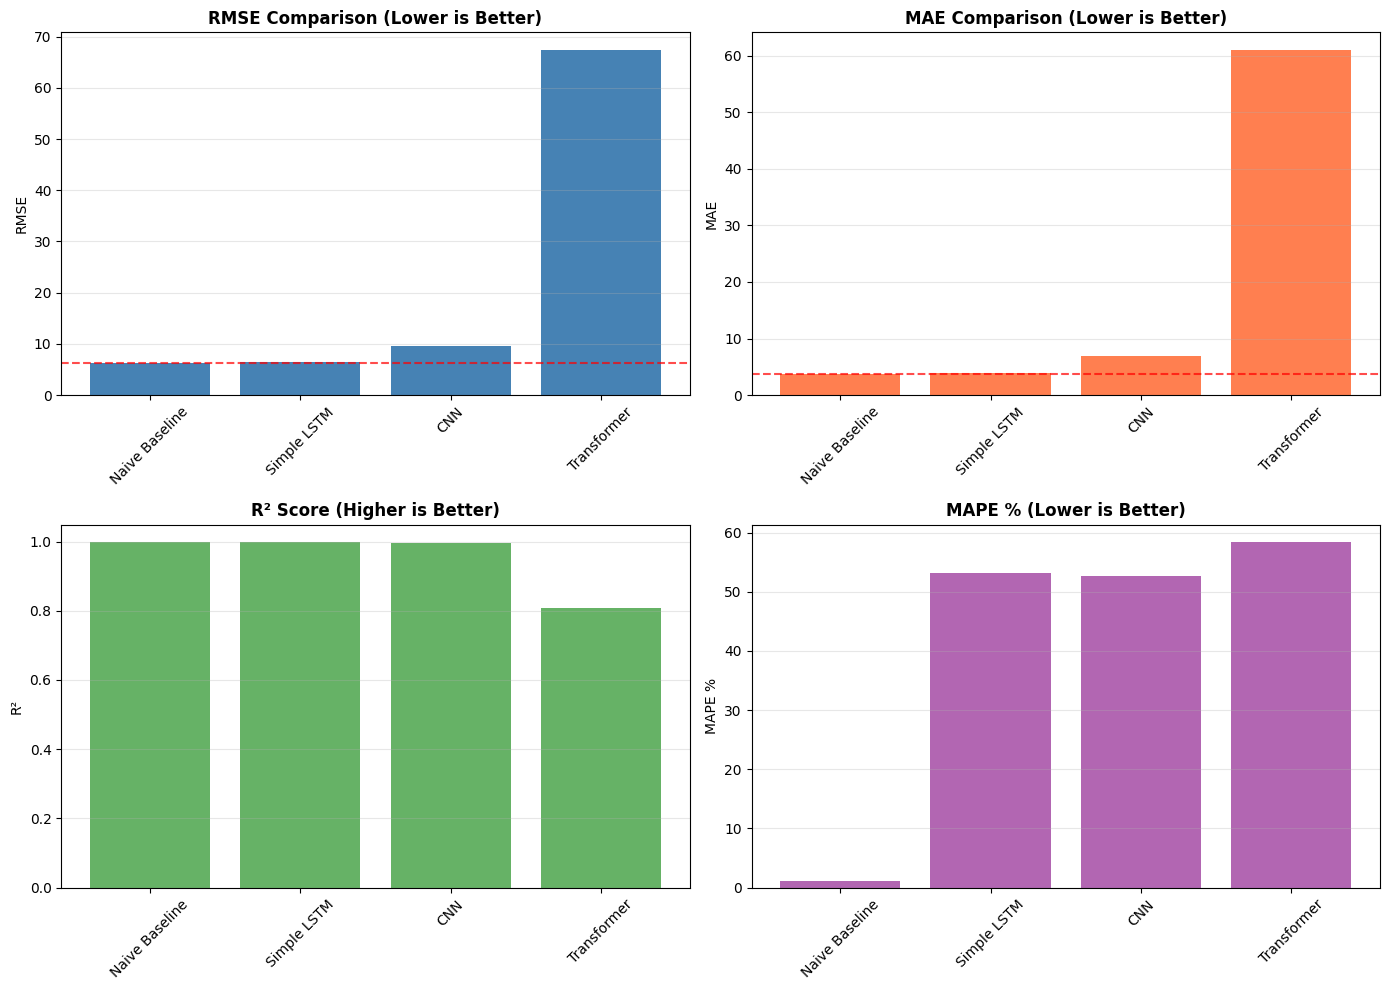

In [43]:
# Bar chart comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(results_df['Model'], results_df['RMSE'], color='steelblue')
axes[0, 0].set_title('RMSE Comparison (Lower is Better)', fontweight='bold')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].axhline(y=baseline_rmse, color='red', linestyle='--', label='Baseline', alpha=0.7)

axes[0, 1].bar(results_df['Model'], results_df['MAE'], color='coral')
axes[0, 1].set_title('MAE Comparison (Lower is Better)', fontweight='bold')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].axhline(y=baseline_mae, color='red', linestyle='--', label='Baseline', alpha=0.7)

axes[1, 0].bar(results_df['Model'], results_df['R²'], color='green', alpha=0.6)
axes[1, 0].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[1, 0].set_ylabel('R²')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(results_df['Model'], results_df['MAPE (%)'], color='purple', alpha=0.6)
axes[1, 1].set_title('MAPE % (Lower is Better)', fontweight='bold')
axes[1, 1].set_ylabel('MAPE %')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 12. Summary - Honest Assessment (FIX #3)

In [44]:
print("\n" + "="*70)
print("SUMMARY AND CONCLUSIONS")
print("="*70)
print(f"\n📈 Banks analyzed: {len(np.unique(company_ids))} commercial banks")
print(f"📈 Total sequences: {len(X):,}")
print(f"📈 Sequence length: {SEQ_LENGTH} days")
print(f"📈 Temporal split: {len(X_train):,} train / {len(X_test):,} test")

print("\n" + "-"*70)
print("Model Performance Ranking (by RMSE):")
print("-"*70)
for idx, row in results_df.iterrows():
    marker = "🏆" if idx == results_df.index[0] else " "
    print(f"{marker} {row['Model']:20s} - RMSE: {row['RMSE']:.4f}, MAE: {row['MAE']:.4f}, R²: {row['R²']:.4f}")

print("\n" + "-"*70)
print("KEY IMPROVEMENTS IMPLEMENTED:")
print("-"*70)
print("✅ FIX #1: Scaler fitted ONLY on training data (no leakage)")
print("✅ FIX #2: Temporal split respects chronological order")
print("✅ FIX #3: R² interpreted honestly (compared to baseline)")
print("✅ FIX #4: Naive baseline included for fair comparison")

print("\n" + "-"*70)
print("INTERPRETATION:")
print("-"*70)
if best_model == 'Naive Baseline':
    print("⚠️  Models don't beat naive baseline → not useful for trading")
    print("   High R² is misleading - just capturing autocorrelation")
else:
    improvement = (1 - results_df[results_df['Model'] == best_model]['RMSE'].values[0] / baseline_rmse) * 100
    print(f"✓ {best_model} beats baseline by {improvement:.1f}%")
    print(f"   This improvement may be useful for practical application")
    if improvement < 10:
        print(f"   However, {improvement:.1f}% improvement is marginal")

print("\n" + "="*70)


SUMMARY AND CONCLUSIONS

📈 Banks analyzed: 17 commercial banks
📈 Total sequences: 52,553
📈 Sequence length: 30 days
📈 Temporal split: 40,064 train / 12,489 test

----------------------------------------------------------------------
Model Performance Ranking (by RMSE):
----------------------------------------------------------------------
🏆 Naive Baseline       - RMSE: 6.2629, MAE: 3.6996, R²: 0.9983
  Simple LSTM          - RMSE: 6.5168, MAE: 3.9321, R²: 0.9982
  CNN                  - RMSE: 9.6319, MAE: 6.8958, R²: 0.9961
  Transformer          - RMSE: 67.4647, MAE: 61.0741, R²: 0.8080

----------------------------------------------------------------------
KEY IMPROVEMENTS IMPLEMENTED:
----------------------------------------------------------------------
✅ FIX #1: Scaler fitted ONLY on training data (no leakage)
✅ FIX #2: Temporal split respects chronological order
✅ FIX #3: R² interpreted honestly (compared to baseline)
✅ FIX #4: Naive baseline included for fair comparison

------